<a href="https://colab.research.google.com/github/tasamu61/MyAiStudyPre/blob/main/8.DimensionReduction256/08-1DimReduction256.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 次元削減（256→K）で判定結果は変わるか？

16×16（＝256次元）のドットパターンをPCAでK次元に圧縮し、「256次元のまま判定した場合」と
「K次元に圧縮してから判定した場合」で、判定結果（分類結果）が変わるかを確認する実験である。

流れは以下の通りである。

1. 6種類の基本パターン（十字・丸・斜め線・市松模様・バツ・ランダム）を用意する
2. ノイズレベルを変えると見た目がどれくらい変わるかを、先に目で確認する
3. それぞれにノイズを混ぜた学習データを大量に作る
4. 学習データだけでPCAを学習させ、256次元→K次元に圧縮する
5. 「256次元のまま判定する分類器」と「K次元に減らして判定する分類器」を用意する
6. 学習に使っていない新しい推論用データ（未知データ）で両方に判定させ、結果を比較する

Colabの各セルを上から順に実行すればよい。

## 1. 準備

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

N = 16  # 16x16 = 256次元


### 日本語フォントの設定（Colab向け）

Colabの初期状態だとグラフの日本語が文字化け（`Glyph ... missing`という警告）するため、
日本語フォントを1回だけインストールして設定しておく。

In [ ]:
!apt-get -qq -y install fonts-noto-cjk > /dev/null 2>&1

import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=["/usr/share/fonts"]):
    if "NotoSansCJK" in f:
        fm.fontManager.addfont(f)
plt.rcParams["font.family"] = "Noto Sans CJK JP"


## 2. 実験の設定（変更したいときはここだけ直せばよい）

この実験に関わるパラメータは以下の5つに集約してある。値を変えたら、このセルから
下を順に再実行すれば、その設定で結果が再計算される。

In [ ]:
# ============================================================
# 実験パラメータ（ここをまとめて変更する）
# ------------------------------------------------------------
K                 = 16    # 圧縮後の次元数(256 -> K)。小さいほど圧縮が強い
N_TRAIN_PER_CLASS = 20    # 学習データの件数(1クラスあたり)
TRAIN_NOISE       = 0.05  # 学習データのノイズ率(0.05 = 5%)
N_TEST_PER_CLASS  = 20    # 推論用データの件数(1クラスあたり)。図形ごとにこの件数で正解率を集計する
TEST_NOISE        = 0.10  # 推論用データのノイズ率(0.10 = 10%)。学習時とは別に新規生成する
# ============================================================

# データ生成専用の乱数生成器。
# 下の「3. ノイズレベルを目で確認する」のボタン操作はこれとは別の乱数を使うので、
# ボタンを何回押しても、ここでの学習・推論データの中身は変わらない（再現性がある）。
rng = np.random.default_rng(42)


## 3. 基本パターン（6クラス）を作る

「十字」「丸」「斜め線」「市松模様」「バツ」の5つは固定の形として定義する。「ランダム」だけは
形を持たず、毎回0/1をランダムに並べたものをそのクラスの実体とする。

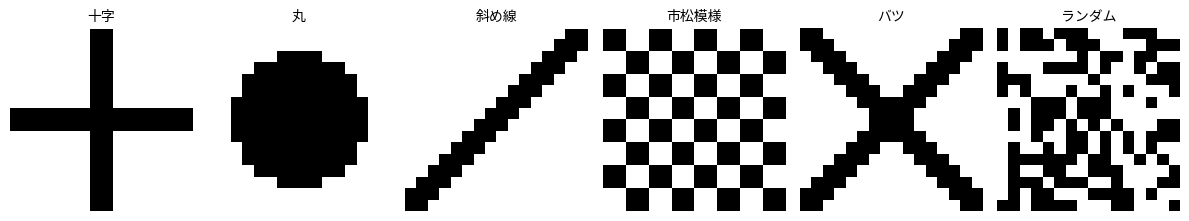

In [ ]:
yy, xx = np.mgrid[0:N, 0:N]
cx = cy = (N - 1) / 2
r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

base = {
    "十字":   (((xx == 7) | (xx == 8)) | ((yy == 7) | (yy == 8))).astype(float),
    "丸":     (r <= 6).astype(float),
    "斜め線":  (np.abs((N - 1 - yy) - xx) <= 1).astype(float),
    "市松模様": ((xx // 2 + yy // 2) % 2 == 0).astype(float),
    "バツ":   ((np.abs((N - 1 - yy) - xx) <= 1) | (np.abs(yy - xx) <= 1)).astype(float),
}
classes = list(base.keys()) + ["ランダム"]  # 合計6クラス

fig, axes = plt.subplots(1, len(classes), figsize=(2*len(classes), 2.2))
for ax, cls in zip(axes, classes):
    img = base[cls] if cls != "ランダム" else (rng.random((N, N)) > 0.5).astype(float)
    ax.imshow(img, cmap="Greys", vmin=0, vmax=1)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. ノイズレベルを目で確認する（インタラクティブ）

「ノイズ5%」と言われても、どれくらい見た目が変わるのかは分かりにくい。そこで先に、
ボタンを押すとノイズレベルが切り替わるインタラクティブな確認セルを用意した。

用意したノイズ水準は **0, 3, 5, 7, 10, 20, 30, 40 %** である。このセルは確認専用の
乱数生成器(`preview_rng`)を使っており、上の実験データ用の`rng`とは完全に独立している。
ボタンを何回押しても、2.で設定した実験の結果には一切影響しない。

> **Colab上でのクリック操作について**：Webページのように「画面の好きな場所をクリック」
> という自由な操作はノートブックの仕組み上できないが、`ipywidgets`というライブラリの
> ボタン（下のセルの`ToggleButtons`）を押すことで、同じように「クリックしたら表示が
> 切り替わる」操作は可能である。ipywidgetsはColabに標準で入っているため、追加の
> インストールは不要である。

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

preview_rng = np.random.default_rng(123)  # 実験データ用のrngとは別物

def make_noisy_preview(cls, flip_prob):
    img = (preview_rng.random((N, N)) > 0.5).astype(float) if cls == "ランダム" else base[cls].copy()
    flip = preview_rng.random((N, N)) < flip_prob
    return np.where(flip, 1 - img, img)

NOISE_CHOICES = [0, 3, 5, 7, 10, 20, 30, 40]  # ％。ここに挙げた値だけボタンとして表示される
out = widgets.Output()

def show_noise(change=None):
    p = level_buttons.value
    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, len(classes), figsize=(2*len(classes), 2.2))
        for ax, cls in zip(axes, classes):
            ax.imshow(make_noisy_preview(cls, p/100), cmap="Greys", vmin=0, vmax=1)
            ax.set_title(cls, fontsize=10)
            ax.axis("off")
        fig.suptitle(f"ノイズ {p}%", y=1.03)
        plt.tight_layout()
        plt.show()

level_buttons = widgets.ToggleButtons(options=NOISE_CHOICES, description="ノイズ(%)")
level_buttons.observe(show_noise, names="value")
display(level_buttons, out)
show_noise()


ToggleButtons(description='ノイズ(%)', options=(0, 3, 5, 7, 10, 20, 30, 40), value=0)

Output()

## 5. ノイズ入りデータセットを作る

2.で設定した`N_TRAIN_PER_CLASS`・`TRAIN_NOISE`・`N_TEST_PER_CLASS`・`TEST_NOISE`を
使って、学習データと推論用データ（学習には一切使わない未知データ）を作る。

In [ ]:
def make_sample(cls, flip_prob):
    img = (rng.random((N, N)) > 0.5).astype(float) if cls == "ランダム" else base[cls].copy()
    flip = rng.random((N, N)) < flip_prob
    return np.where(flip, 1 - img, img).ravel()

def make_dataset(n_per_class, flip_prob):
    X, y = [], []
    for cls in classes:
        for _ in range(n_per_class):
            X.append(make_sample(cls, flip_prob))
            y.append(cls)
    return np.array(X), np.array(y)

X_train, y_train = make_dataset(N_TRAIN_PER_CLASS, TRAIN_NOISE)
X_infer, y_infer = make_dataset(N_TEST_PER_CLASS, TEST_NOISE)
print(f"学習データ: {X_train.shape[0]}件 x {X_train.shape[1]}次元 (ノイズ{TRAIN_NOISE*100:.0f}%)")
print(f"推論用データ: {X_infer.shape[0]}件 x {X_infer.shape[1]}次元 (ノイズ{TEST_NOISE*100:.0f}%、学習には未使用)")


学習データ: 120件 x 256次元 (ノイズ5%)
推論用データ: 120件 x 256次元 (ノイズ10%、学習には未使用)


## 6. PCAで256次元→K次元に圧縮する

PCAは学習データだけで学習させる（`fit`）。推論用データはその学習済みPCAで変換する
（`transform`）だけにとどめ、推論用データの情報が学習側に漏れないようにする。

In [ ]:
pca = PCA(n_components=K)
X_train_k = pca.fit_transform(X_train)
X_infer_k = pca.transform(X_infer)

cum = pca.explained_variance_ratio_.sum() * 100
print(f"K={K}次元で保持できている情報量（累積寄与率）: {cum:.1f}%")


K=16次元で保持できている情報量（累積寄与率）: 76.9%


### 実際に256→Kになった値の例（各クラス先頭1件）

In [ ]:
seen = set()
for x_k, label in zip(X_train_k, y_train):
    if label in seen:
        continue
    seen.add(label)
    vals = ", ".join(f"{v:6.2f}" for v in x_k)
    print(f"{label:6s}: {vals}")


十字    :   0.30,   4.69,  -3.46,  -1.19,   0.80,   0.07,  -0.33,  -0.34,  -0.32,  -0.18,   0.00,  -0.03,   0.23,   0.09,   0.07,   0.12
丸     :   0.79,   3.56,   4.53,  -0.64,  -0.59,   0.11,  -0.09,   0.14,   0.08,  -0.18,   0.10,   0.16,   0.06,   0.11,  -0.22,  -0.28
斜め線   :  -4.79,  -1.05,  -1.32,  -0.02,  -2.58,  -0.15,  -0.05,   0.00,   0.15,  -0.33,   0.19,   0.17,  -0.19,  -0.07,   0.09,  -0.12
市松模様  :   5.25,  -3.81,  -0.02,  -1.24,  -0.74,   0.33,   0.17,   0.16,  -0.46,   0.40,   0.45,   0.03,   0.46,   0.50,  -0.10,   0.65
バツ    :  -3.78,  -3.21,   1.51,  -1.19,   2.07,  -0.16,  -0.20,   0.31,  -0.06,  -0.05,   0.02,  -0.35,  -0.24,   0.38,  -0.30,   0.09
ランダム  :   1.06,   0.48,   0.19,   4.32,   0.67,   2.12,   2.35,   0.51,  -0.40,  -0.06,   1.48,  -0.06,  -1.07,  -2.31,  -3.92,   1.55


## 7. 「256次元のまま判定する分類器」と「K次元に減らして判定する分類器」

判定方法（分類器）はどちらも同じ、k近傍法（k-NN, k=3）を使う。違いは入力する特徴量の
次元数だけである。

In [ ]:
clf_256 = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
clf_k   = KNeighborsClassifier(n_neighbors=3).fit(X_train_k, y_train)

pred_256 = clf_256.predict(X_infer)
pred_k   = clf_k.predict(X_infer_k)


## 8. 図形ごとに集計し、一覧で見る

推論用データは6クラス×`N_TEST_PER_CLASS`件ある。1件ずつ見るのではなく、**図形（クラス）
ごとにまとめて集計**し、「256次元での正解率」「K次元での正解率」「256次元とK次元で
判定が一致した割合」を一覧で比較する。使った設定値もあわせて表示する。

In [ ]:
print(f"[設定] K={K}  学習={N_TRAIN_PER_CLASS}件/クラス(ノイズ{TRAIN_NOISE*100:.0f}%)"
      f"  推論={N_TEST_PER_CLASS}件/クラス(ノイズ{TEST_NOISE*100:.0f}%)\n")

rows = []
for cls in classes:
    idx = [i for i, t in enumerate(y_infer) if t == cls]
    n = len(idx)
    acc256 = sum(pred_256[i] == cls for i in idx) / n * 100
    acck   = sum(pred_k[i] == cls for i in idx) / n * 100
    agree  = sum(pred_256[i] == pred_k[i] for i in idx) / n * 100
    rows.append((cls, n, acc256, acck, agree))

print(f"{'図形':8s}{'件数':>6s}{'256次元正解率':>14s}{'K次元正解率':>12s}{'256とK一致率':>12s}")
for cls, n, a256, ak, ag in rows:
    print(f"{cls:8s}{n:>5d}件{a256:>12.1f}%{ak:>11.1f}%{ag:>11.1f}%")

total_agree = (pred_256 == pred_k).sum()
print(f"\n全体: 256次元正解率={sum(pred_256==y_infer)/len(y_infer)*100:.1f}%  "
      f"K次元正解率={sum(pred_k==y_infer)/len(y_infer)*100:.1f}%  "
      f"一致={total_agree}/{len(y_infer)}件")


[設定] K=16  学習=20件/クラス(ノイズ5%)  推論=20件/クラス(ノイズ10%)

図形          件数      256次元正解率      K次元正解率    256とK一致率
十字         20件       100.0%      100.0%      100.0%
丸          20件       100.0%      100.0%      100.0%
斜め線        20件       100.0%      100.0%      100.0%
市松模様       20件       100.0%      100.0%      100.0%
バツ         20件       100.0%      100.0%      100.0%
ランダム       20件        55.0%       95.0%       60.0%

全体: 256次元正解率=92.5%  K次元正解率=99.2%  一致=112/120件


## 9. 考察

`K` / `N_TRAIN_PER_CLASS` / `TRAIN_NOISE` / `N_TEST_PER_CLASS` / `TEST_NOISE` の
どれを変えても、2.のセルから再実行すれば結果に反映される。一般的な傾向は以下の通りである。

- **Kを極端に小さくする**（例: 2〜4）と、情報を削りすぎて正解率が256次元より明確に
  下がりやすい。
- **Kを適度な値（今回なら16前後）にする**と、ノイズの影響が主成分の外側（寄与率の低い
  成分）に押し出され、256次元よりもむしろ正解率が上がることがある。これはPCAが
  結果的にノイズ除去のような働きをするためである。
- **学習データの件数(`N_TRAIN_PER_CLASS`)や推論データの件数(`N_TEST_PER_CLASS`)を
  大きく変えると、上とは違う傾向が出ることもある。** 件数を大きく変えて試す場合は、
  必ず2.のセルからやり直し、4.のボタンを一切押さずに5.以降を実行してから結果を
  比較してほしい（4.のボタンは独立した乱数を使うよう直したが、念のため実験の
  再現性を保つためには2.から順番に実行するのが確実である）。

## 10. 量子化（次元削減だけではデータ量は減らない）

ここまでの「256次元→K次元」は、あくまで**floatの個数**を減らしただけである。1個の値を
float64（8バイト）のまま持っていると、K=16でも16×8＝128バイトになり、元画像を
1ビット/画素で保存した場合（256/8＝32バイト）より**むしろ大きい**。

実際にデータ量を減らすには、この16個の値それぞれを何ビットで表すか（量子化）を
別途決める必要がある。学習データ側の最小・最大だけを覚えておき、その範囲をB段階に
区切って整数に丸める、という最も単純な量子化を試す。

In [ ]:
def quantize(X, bits, vmin, vmax):
    """連続値Xを2**bits段階の整数に丸める(量子化)。"""
    levels = 2**bits - 1
    q = np.round((X - vmin) / (vmax - vmin + 1e-12) * levels)
    return np.clip(q, 0, levels)

def dequantize(q, bits, vmin, vmax):
    """量子化した整数を、判定に使うためもとの範囲に戻す。"""
    levels = 2**bits - 1
    return q / levels * (vmax - vmin) + vmin

# 量子化の範囲(vmin, vmax)は学習データだけから決める(推論データの情報を混ぜない)
vmin = X_train_k.min(axis=0)
vmax = X_train_k.max(axis=0)
n_test = len(y_infer)

# 256次元そのまま(削減前)の正解率。もともと0/1の2値なので1ビット/画素が最小表現。
clf256 = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
acc256 = (clf256.predict(X_infer) == y_infer).mean() * 100

rows = [("256次元(削減前,1bit/画素)", 256/8, acc256)]
for bits in [64, 8, 6, 4, 3, 2, 1]:
    if bits == 64:
        Xtr_q, Xte_q, nbytes, label = X_train_k, X_infer_k, K*8, f"{K}次元 float64(量子化なし)"
    else:
        Xtr_q = dequantize(quantize(X_train_k, bits, vmin, vmax), bits, vmin, vmax)
        Xte_q = dequantize(quantize(X_infer_k, bits, vmin, vmax), bits, vmin, vmax)
        nbytes, label = K*bits/8, f"{K}次元 {bits}bit量子化"
    clf = KNeighborsClassifier(n_neighbors=3).fit(Xtr_q, y_train)
    acc = (clf.predict(Xte_q) == y_infer).mean() * 100
    rows.append((label, nbytes, acc))

print(f"{'表現':30s}{'1件(B)':>9s}{'全体'+str(n_test)+'件(B)':>14s}{'正解率':>9s}")
for label, nbytes, acc in rows:
    print(f"{label:30s}{nbytes:>8.1f}B{nbytes*n_test:>13,.0f}B{acc:>8.1f}%")


表現                                1件(B)     全体120件(B)      正解率
256次元(削減前,1bit/画素)                32.0B        3,840B    92.5%
16次元 float64(量子化なし)              128.0B       15,360B    99.2%
16次元 8bit量子化                      16.0B        1,920B    99.2%
16次元 6bit量子化                      12.0B        1,440B    98.3%
16次元 4bit量子化                       8.0B          960B    97.5%
16次元 3bit量子化                       6.0B          720B    95.8%
16次元 2bit量子化                       4.0B          480B    96.7%
16次元 1bit量子化                       2.0B          240B    90.0%


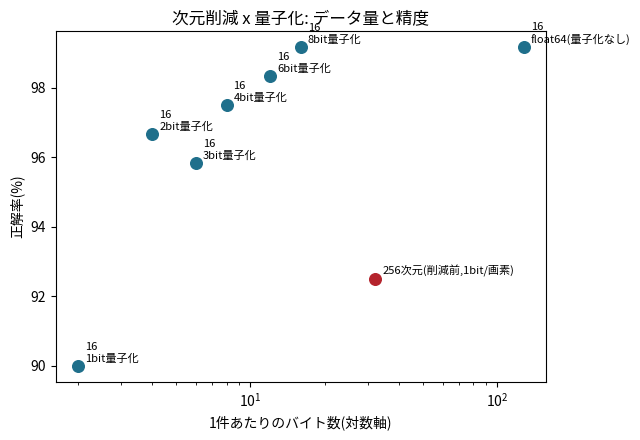

In [ ]:
# 結果をグラフにして見やすくする(横軸:1件のバイト数[対数], 縦軸:正解率)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, nbytes, acc in rows:
    color = "#b4232c" if "削減前" in label else "#1f6f8b"
    ax.scatter(nbytes, acc, color=color, s=70, zorder=3)
    ax.annotate(label.replace("次元 ", "\n"), (nbytes, acc), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("1件あたりのバイト数(対数軸)")
ax.set_ylabel("正解率(%)")
ax.set_title("次元削減 x 量子化: データ量と精度")
plt.tight_layout()
plt.show()


## 11. （参考）符号付きランダム射影：最初からビットを出す方法

量子化は「floatで求めてから丸める」という2段階だが、学習を一切せず**最初からビット列
そのものを出す**方法もある。ランダムな方向をいくつか用意し、データとの内積の符号
（＋なら1、－なら0）だけを採用する。PCAのように「良い方向」を選んでいないため、
このデータでは同じビット数でも量子化(10.)ほどの精度は出ない。参考として結果だけ載せる。

In [ ]:
def signed_random_projection(X, planes):
    # 内積の符号だけを取り出し、そのまま0/1のビットにする(学習データを一切見ない)
    return (X @ planes > 0).astype(int)

srp_rng = np.random.default_rng(7)  # 方向を決めるだけの乱数。学習データには依存しない
rows_srp = []
for B in [16, 8, 4, 2]:
    planes = srp_rng.normal(size=(X_train.shape[1], B))  # ランダムな方向をB本用意
    Btr = signed_random_projection(X_train, planes)
    Bte = signed_random_projection(X_infer, planes)
    # ビット列同士なのでハミング距離(何ビット違うか)でk-NNを行う
    clf = KNeighborsClassifier(n_neighbors=3, metric="hamming").fit(Btr, y_train)
    acc = (clf.predict(Bte) == y_infer).mean() * 100
    rows_srp.append((B, B/8, acc))

print(f"{'ビット数':>8s}{'1件(B)':>9s}{'正解率':>9s}")
for B, nbytes, acc in rows_srp:
    print(f"{B:>7d}b{nbytes:>8.1f}B{acc:>8.1f}%")
print(f"\n(比較) 256次元そのまま: {acc256:.1f}%")
print(f"(比較) {K}次元 2bit量子化(10.の結果): {[r[2] for r in rows if '2bit' in r[0]][0]:.1f}%")


    ビット数    1件(B)      正解率
     16b     2.0B    71.7%
      8b     1.0B    51.7%
      4b     0.5B    33.3%
      2b     0.2B    15.0%

(比較) 256次元そのまま: 92.5%
(比較) 16次元 2bit量子化(10.の結果): 96.7%


## まとめ

今回の一連の実験は、大きく3つに分けられる。

1. **クルマの諸元の次元削減**（別ファイル`PCA2D.java`・`PCA2D_explanation.md`）：少数の、
   単位がバラバラな諸元をPCAで2次元にする、次元削減の基本形。
2. **16×16パターンの次元削減＋量子化**（このノートブックの本体）：次元（floatの個数）を
   減らすことと、1個の値の精度（ビット数）を減らすことは別問題であり、**両方を組み合わせて
   初めて意味のあるデータ量削減になる**ことを確認した。
3. **（参考）符号付きランダム射影**：学習せずに最初からビットを出す方法もあるが、
   「良い方向を選ぶ」というPCAの強みを放棄する分、同じビット数では精度が劣ることを確認した。